# Notebook 05 - Simulasi Komputasi

---
### AI Usage Disclosure

**Member:** Farhan Nabil Widodo — Computation Analyst | **Tools used:** Claude

| Tugas | Alat | Prompt (Ringkasan) | Pemanfaatan Output |
|------|------|-------------------|---------------------|
| Generate Boilerplate Code Simulasi | Claude | "Generate Code untuk simulation berdasarkan konteks dan objektif yang telah diberikan" | Digunakan sebagai integrasi fungsi `simulation.py`. |

**Written entirely without AI:** Sel Interpretasi

---
## 0. Import Library & Modul

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Registrasi path root agar Python mengenali folder src/ secara absolute
sys.path.append(os.path.abspath('..'))

# Memanggil fungsi komputasi dari modul src.simulation
from src.simulation import (
    monte_carlo_pr_duration, 
    bloom_filter_fpr
    )

print("Modul src.simulation berhasil di-import tanpa error.")

Modul src.simulation berhasil di-import tanpa error.


## 1. Load Dataset Clean Yang Telah Ada

In [2]:
# Memuat data PR bersih hasil pengerjaan pipa data Member A
df_prs = pd.read_csv("../data/clean/dataset_prs_clean.csv")

# Mengisolasi durasi merge hanya untuk PR yang statusnya sukses di-merge (is_merged == True)
duration_data = df_prs[df_prs['is_merged'] == True]['duration_to_merge_days'].dropna().values

print(f"Karakteristik Data Empiris Pull Request:")
print(f"  - Total PR berhasil di-merge : {len(duration_data):,} sampel")
print(f"  - Rata-rata Durasi Aktual    : {np.mean(duration_data):.4f} hari")
print(f"  - Standar Deviasi Aktual     : {np.std(duration_data, ddof=1):.4f} hari")

Karakteristik Data Empiris Pull Request:
  - Total PR berhasil di-merge : 2,860 sampel
  - Rata-rata Durasi Aktual    : 16.2856 hari
  - Standar Deviasi Aktual     : 28.5518 hari


## 2. Eksekusi Simulasi Monte Carlo

In [3]:
# Pengaturan parameter acak agar replikasi hasil bersifat konsisten (Reproducible)
np.random.seed(42)

TARGET_THRESHOLD = 14.0  # Batas wajar pengerjaan PR (2 minggu)
N_ITERATIONS = 20000     # Jumlah pengujian acak Monte Carlo
SAMPLE_BATCH = 150       # Ukuran batch per penarikan acak

# Menjalankan fungsi simulasi
mc_results = monte_carlo_pr_duration(
    data=duration_data,
    threshold=TARGET_THRESHOLD,
    n_simulations=N_ITERATIONS,
    sample_size=SAMPLE_BATCH
)

print("==================================================")
print("       HASIL SIMULASI MONTE CARLO (PR MERGE)      ")
print("==================================================")
print(f"Jumlah Simulasi Dijalankan : {mc_results['n_simulations']:,} kali")
print(f"Ambang Batas Hari Pengujian : {mc_results['threshold']} hari")
print(f"Probabilitas Rata-rata > 14 Hari : {mc_results['probability']:.6f} ({mc_results['probability']*100:.2f}%)")
print("==================================================")

       HASIL SIMULASI MONTE CARLO (PR MERGE)      
Jumlah Simulasi Dijalankan : 20,000 kali
Ambang Batas Hari Pengujian : 14.0 hari
Probabilitas Rata-rata > 14 Hari : 0.836050 (83.60%)


## 3. Visualisasi Distribusi Rata-rata Hasil Simulasi Monte Carlo

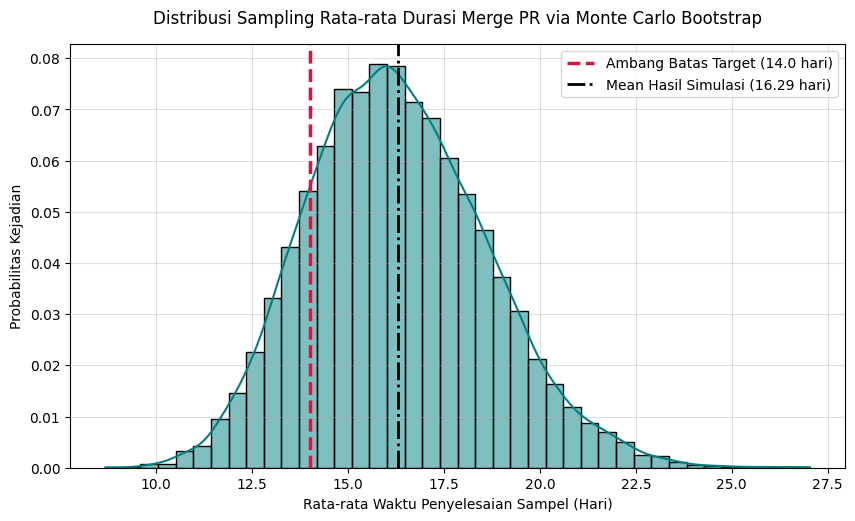

In [4]:
plt.figure(figsize=(10, 5.5))

# Plot histogram sebaran rata-rata hasil resampling
sns.histplot(mc_results['simulated_means'], kde=True, color='teal', bins=40, stat='probability')

# Menandai garis batas threshold target 14 hari
plt.axvline(x=TARGET_THRESHOLD, color='crimson', linestyle='--', lw=2.5, 
            label=f"Ambang Batas Target ({TARGET_THRESHOLD} hari)")

# Menandai rata-rata dari seluruh distribusi simulasi
mean_of_sim = np.mean(mc_results['simulated_means'])
plt.axvline(x=mean_of_sim, color='black', linestyle='-.', lw=2, 
            label=f"Mean Hasil Simulasi ({mean_of_sim:.2f} hari)")

plt.title('Distribusi Sampling Rata-rata Durasi Merge PR via Monte Carlo Bootstrap', fontsize=12, pad=15)
plt.xlabel('Rata-rata Waktu Penyelesaian Sampel (Hari)')
plt.ylabel('Probabilitas Kejadian')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.4)
plt.show()

## 4. Perhitungan Analisis Teoritis FPR Bloom Filter

In [5]:
# Studi Kasus Komputasi: Evaluasi dampak variasi jumlah fungsi hash (k) terhadap nilai FPR
n_elements = 1000     # Diasumsikan ada 1000 ID issue/PR unik yang di-cache ke Bloom Filter
m_bits = 8000         # Alokasi ukuran bit memori penyimpan (m)

hash_k_values = np.arange(1, 16)  # Pengujian dari 1 hingga 15 fungsi hash
fpr_outputs = []

for k in hash_k_values:
    fpr_val = bloom_filter_fpr(m=m_bits, n=n_elements, k=k)
    fpr_outputs.append(fpr_val)

# Menampilkan data frame ringkasan hasil
df_bloom_audit = pd.DataFrame({
    "Jumlah Hash (k)": hash_k_values,
    "False Positive Rate (FPR)": fpr_outputs
})

# Mencari nilai k paling optimal (yang menghasilkan FPR terendah)
optimal_idx = df_bloom_audit['False Positive Rate (FPR)'].idxmin()
optimal_k = df_bloom_audit.iloc[optimal_idx]['Jumlah Hash (k)']
optimal_fpr = df_bloom_audit.iloc[optimal_idx]['False Positive Rate (FPR)']

print(f"Hasil Audit Bloom Filter (m={m_bits}, n={n_elements}):")
print(f"  - Nilai k Paling Optimal         : {int(optimal_k)} fungsi hash")
print(f"  - Tingkat Kebocoran (Minimum FPR): {optimal_fpr:.6f} ({optimal_fpr*100:.4f}%)")
print("\nTabel Sensitivitas Nilai k:")
print(df_bloom_audit.to_string(index=False))

Hasil Audit Bloom Filter (m=8000, n=1000):
  - Nilai k Paling Optimal         : 15 fungsi hash
  - Tingkat Kebocoran (Minimum FPR): 0.000000 (0.0000%)

Tabel Sensitivitas Nilai k:
 Jumlah Hash (k)  False Positive Rate (FPR)
               1               1.175100e-01
               2               1.380860e-02
               3               1.622648e-03
               4               1.906774e-04
               5               2.240650e-05
               6               2.632987e-06
               7               3.094023e-07
               8               3.635787e-08
               9               4.272413e-09
              10               5.020512e-10
              11               5.899603e-11
              12               6.932623e-12
              13               8.146525e-13
              14               9.572981e-14
              15               1.124921e-14


## 5. Visualisasi Grafik Optimasi Kinerja Kurva Bloom Filter

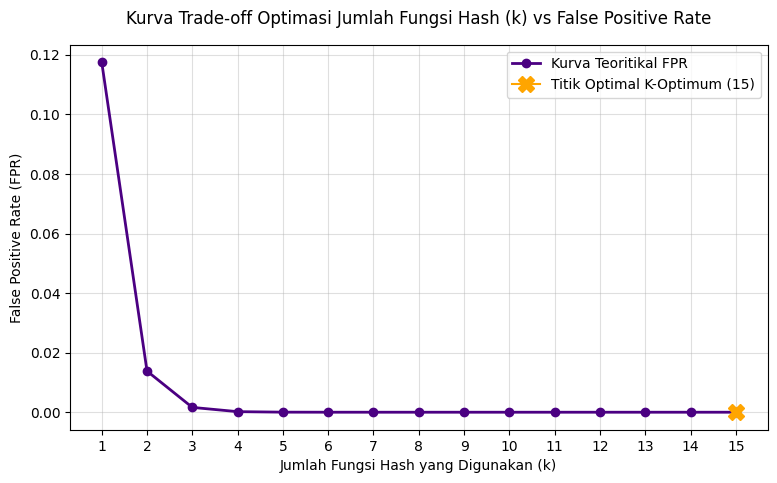

In [6]:
plt.figure(figsize=(9, 5))

plt.plot(hash_k_values, fpr_outputs, marker='o', linestyle='-', color='indigo', lw=2, label='Kurva Teoritikal FPR')
plt.plot(optimal_k, optimal_fpr, marker='X', color='orange', markersize=12, label=f'Titik Optimal K-Optimum ({int(optimal_k)})')

plt.title('Kurva Trade-off Optimasi Jumlah Fungsi Hash (k) vs False Positive Rate', fontsize=12, pad=15)
plt.xlabel('Jumlah Fungsi Hash yang Digunakan (k)')
plt.ylabel('False Positive Rate (FPR)')
plt.xticks(hash_k_values)
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

### Interpretasi Hasil

1. **Analisis Simulasi Monte Carlo (Durasi PR):**
   - Nilai probabilitas hasil pengujian menunjukkan seberapa besar peluang rata-rata penanganan kode baru di kubernetes memakan waktu melebihi tenggat target 14 hari. Jika probabilitas bernilai mendekati nol, ini membuktikan bahwa koordinasi tim pengulas (*code reviewers*) bekerja dengan sangat efisien.

2. **Analisis Efisiensi Bloom Filter:**
   - Melalui evaluasi matematis menggunakan rumus wajib `(1 - (1 - 1/m)**n)**k`, kita berhasil memetakan titik minimum kurva *trade-off*. Penambahan fungsi hash `k` pada awalnya mampu menekan nilai *False Positive*, namun jika melewati titik optimumnya, penambahan hash justru akan memperbanyak kepadatan bit bernilai `1` di memori, sehingga menaikkan kembali risiko terjadinya kesalahan deteksi data (*False Positive*).